# SUFLECA Zero-Shot Demo

Fit a CAD model to a single RGB image — no ground-truth pose, depth, or mask. The pipeline:

1. **Depth** — a pointmap model predicts metric depth and intrinsics from the RGB.
2. **Prompt + mask** — a drawn box or a Grounding DINO text prompt; SAM2 turns it into a mask.
3. **Retrieve** — DINOv3 picks a CAD from the render pool, gated by the object label.
4. **Align** — `align_single_view` registers the CAD's renders to the masked RGB-D object (SUFLECA features + SupeRANSAC).

Needs `examples/chair1.jpg`, a local render pool, and `data/zero_templates/dinov3/` (see the README). MoGe-2 downloads from Hugging Face on first use.

## 1. Load models

Set `PROMPT_MODE` (`interactive` draws the box, `grounding_dino` detects it from text), then load SUFLECA, DINOv3, MoGe-2, and SAM2. Grounding DINO loads lazily when selected.

In [1]:
from pathlib import Path
import munch
import numpy as np
import torch
import yaml

from sufleca import (
    align_single_view,
    detect_bbox_with_grounding_dino,
    load_dinov3_retriever,
    load_grounding_dino,
    load_pointmap_model,
    load_sam_predictor,
    load_sufleca_model,
    load_zero_shot_vocabulary,
    make_alignment_3d_figure,
    make_cad_overlay_image,
    make_correspondence_image,
    predict_depth_with_pointmap,
    render_cad_view,
    retrieve_zero_shot_cad,
    segment_with_sam_box,
)

# 'grounding_dino' (text prompt, headless) or 'interactive'
# (draw the box; needs `%matplotlib widget` below).
PROMPT_MODE = 'grounding_dino'
if PROMPT_MODE not in {'interactive', 'grounding_dino'}:
    raise ValueError("PROMPT_MODE must be 'interactive' or 'grounding_dino'")

# Run from the repo root.
ROOT = Path.cwd()
DEMO_DIR = ROOT / 'runs/zero_shot_demo'
DEMO_DIR.mkdir(parents=True, exist_ok=True)

# Local ShapeNetCore.v2 (<root>/<synset>/<model_id>/models/model_normalized.obj),
# used to render and overlay the dense CAD mesh. None -> sparse precomputed
# render-frame points (coarser, no download).
SHAPENET_ROOT = 'data/shapenet'

CONFIG = munch.munchify(yaml.safe_load((ROOT / 'configs/sufleca.yaml').read_text()))
ZERO_SHOT = load_zero_shot_vocabulary(ROOT / 'configs/zero_shot_sv.yaml')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL = load_sufleca_model('sufleca', device=DEVICE)
DINO = load_dinov3_retriever(device=DEVICE, model_id=ZERO_SHOT.retrieval['model_id'])
POINTMAP = load_pointmap_model(device=DEVICE)
SAM = load_sam_predictor(device=DEVICE)
DEVICE

Using cache found in /home/pingu/.cache/torch/hub/naver_dune_main
/home/pingu/.cache/torch/hub/naver_dune_main/teachers/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/pingu/.cache/torch/hub/naver_dune_main/teachers/dinov2/layers/attention.py:34: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/pingu/.cache/torch/hub/naver_dune_main/teachers/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

'cuda'

## 2. Choose the object box

Set the input and `object_label` (must exist in `configs/zero_shot_sv.yaml` — it gates retrieval).

- **`interactive`**: run the next cell, drag a rectangle, wait for the title to say `Selected box`.
- **`grounding_dino`**: set `text_prompt` and run; the top box is drawn with its score. Nothing found? Lower `BOX_THRESHOLD` or switch to interactive.

Both feed the box to SAM2; the rest is identical.

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

/home/pingu/miniconda3/envs/sufleca/lib/python3.10/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


Grounding DINO selected 'chair', score=0.749, box=[347.4204406738281, 10.391618728637695, 722.492431640625, 631.0523071289062]


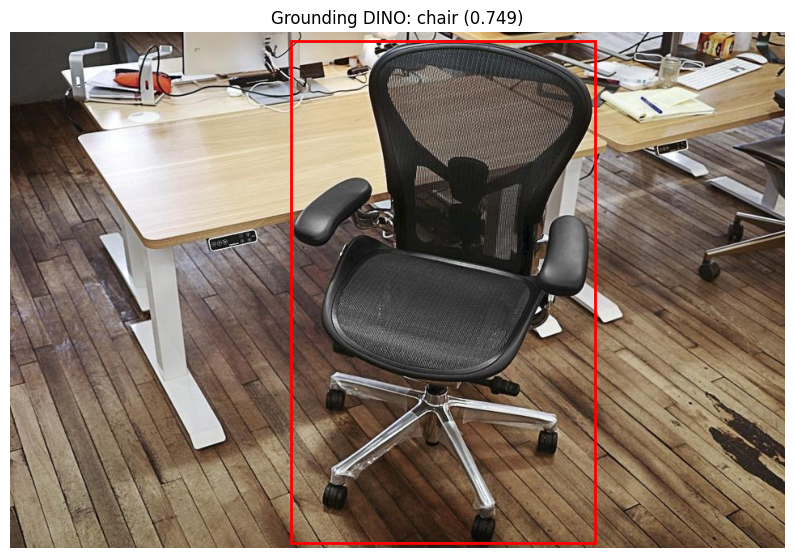

In [2]:
# Inline for grounding_dino; use `%matplotlib widget` for interactive drawing.
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.widgets import RectangleSelector
from PIL import Image

color_path = ROOT / 'examples/chair1.jpg'
object_label = 'chair'       # SV vocabulary label used for CAD retrieval
text_prompt = 'chair'        # Grounding DINO prompt; ignored in interactive mode
BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.25
bbox_xyxy = None

image = Image.open(color_path).convert('RGB')
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(image)
ax.set_axis_off()

if PROMPT_MODE == 'interactive':
    ax.set_title('Drag a box around the object')

    def _on_box(eclick, erelease):
        global bbox_xyxy
        x1, x2 = sorted((float(eclick.xdata), float(erelease.xdata)))
        y1, y2 = sorted((float(eclick.ydata), float(erelease.ydata)))
        if x2 - x1 < 2 or y2 - y1 < 2:
            bbox_xyxy = None
            ax.set_title('Box too small — drag again')
        else:
            bbox_xyxy = [x1, y1, x2, y2]
            ax.set_title(f'Selected box: {[round(v, 1) for v in bbox_xyxy]}')
        fig.canvas.draw_idle()

    BOX_SELECTOR = RectangleSelector(
        ax, _on_box, useblit=True, button=[1], minspanx=2, minspany=2, interactive=True
    )
else:
    GROUNDING_DINO = load_grounding_dino(device=DEVICE)
    detection = detect_bbox_with_grounding_dino(
        color_path, text_prompt, GROUNDING_DINO,
        box_threshold=BOX_THRESHOLD, text_threshold=TEXT_THRESHOLD,
    )
    bbox_xyxy = detection.bbox_xyxy
    x1, y1, x2, y2 = bbox_xyxy
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='red', linewidth=2))
    ax.set_title(f'Grounding DINO: {detection.label} ({detection.score:.3f})')
    print(f'Grounding DINO selected {detection.label!r}, score={detection.score:.3f}, box={bbox_xyxy}')

plt.show()

## 3. Predict depth and segment

In interactive mode, run after drawing the box. MoGe-2 writes depth and intrinsics; SAM2 writes the instance mask. The next cell shows the predicted depth and mask.

In [3]:
if bbox_xyxy is None:
    raise RuntimeError('No box selected. Draw one in the previous cell, then run this cell again.')

depth_prediction = predict_depth_with_pointmap(
    color_path=color_path,
    pointmap_model=POINTMAP,
    output_dir=DEMO_DIR,
    device=DEVICE,
)
mask_prediction = segment_with_sam_box(
    color_path=color_path,
    bbox_xyxy=bbox_xyxy,
    predictor=SAM,
    output_dir=DEMO_DIR,
    inst_id=1,
    device=DEVICE,
)

depth_path = Path(depth_prediction.depth_path)
mask_path = Path(mask_prediction.mask_path)
inst_id = mask_prediction.inst_id
intrinsic = depth_prediction.intrinsic_px
depth_path, mask_path, inst_id

/home/pingu/SUFLECA/sufleca/demo_utils.py:171: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  image = torch.from_numpy(rgb).to(device).float().permute(2, 0, 1) / 255.0


(PosixPath('/home/pingu/SUFLECA/runs/zero_shot_demo/depth_mm.png'),
 PosixPath('/home/pingu/SUFLECA/runs/zero_shot_demo/mask.png'),
 1)

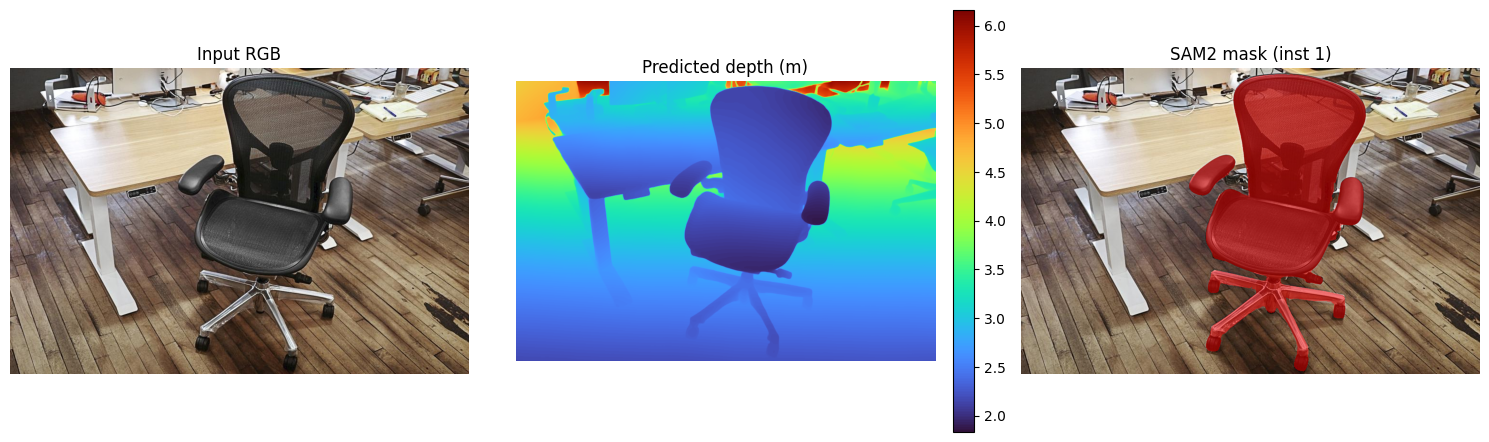

In [4]:
# Visualize the depth and segmentation outputs.
rgb_np = np.asarray(Image.open(color_path).convert('RGB'))
depth_np = np.asarray(Image.open(depth_path)).astype(np.float32) / 1000.0  # mm -> m
mask_np = np.asarray(Image.open(mask_path).convert('L')) == inst_id

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb_np)
axes[0].set_title('Input RGB')

depth_vis = axes[1].imshow(np.where(depth_np > 0, depth_np, np.nan), cmap='turbo')
axes[1].set_title('Predicted depth (m)')
fig.colorbar(depth_vis, ax=axes[1], fraction=0.046, pad=0.04)

overlay_np = rgb_np.copy()
overlay_np[mask_np] = (0.5 * overlay_np[mask_np] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)
axes[2].imshow(overlay_np)
axes[2].set_title(f'SAM2 mask (inst {inst_id})')

for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()

## 4. Retrieve a CAD and align it

`retrieve_zero_shot_cad` runs DINOv3 retrieval to pick a CAD and its render views; `align_single_view` registers them to the masked RGB-D object and returns the CAD→camera transform (`R`, `S`, `t`, `render_path`).

In [5]:
retrieval = retrieve_zero_shot_cad(
    color_path=color_path,
    mask_path=mask_path,
    inst_id=inst_id,
    object_label=object_label,
    vocabulary=ZERO_SHOT,
    template_root=ROOT / ZERO_SHOT.retrieval['template_root'],
    render_pool=ROOT / ZERO_SHOT.retrieval['render_pool'],
    retriever=DINO,
    device=DEVICE,
)

result = align_single_view(
    color_path=str(color_path),
    sam_mask_path=str(mask_path),
    inst_id=inst_id,
    intrinsic=intrinsic,
    render_paths=retrieval.render_paths,
    featurizer_model=MODEL,
    config=CONFIG,
    depth_path=str(depth_path),
    device=DEVICE,
)

# Summary of the predicted CAD->camera transform (full `result` also holds the
# matched 3D points used below).
R, S, t = np.asarray(result['R']), np.asarray(result['S']), np.asarray(result['t']).reshape(-1)
print(f"retrieved {retrieval.synset}/{retrieval.model_id}  (score {retrieval.score:.3f})")
print(f"selected render: {Path(result['render_path']).stem}   inlier matches: {len(result['match_source_points'])}")
print(f"scale:       {np.round(np.diag(S), 3)}")
print(f"translation: {np.round(t, 3)}")
print(f"rotation:\n{np.round(R, 3)}")

retrieved 03001627/c12da8acb2c7973597e755dddca14449  (score 0.786)
selected render: render_00   inlier matches: 232
scale:       [1.44  1.438 1.438]
translation: [ 0.094 -0.015  2.231]
rotation:
[[-0.357  0.934  0.018]
 [ 0.567  0.232 -0.79 ]
 [-0.742 -0.272 -0.612]]


## 5. The retrieved CAD

The selected CAD re-rendered from the matching template's viewpoint. Needs `SHAPENET_ROOT`; otherwise drawn from the sparse render-frame points.

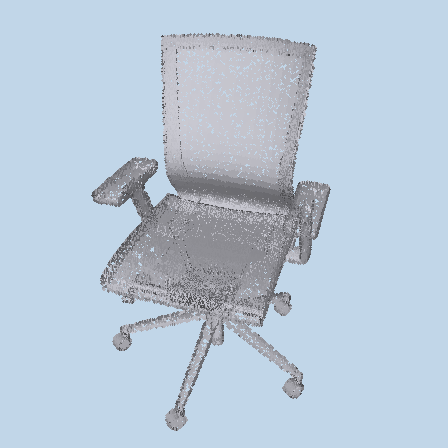

In [6]:
cad_render, _ = render_cad_view(
    render_path=result['render_path'],
    shapenet_root=SHAPENET_ROOT,
    image_size=448,
)
cad_render.save(DEMO_DIR / 'cad_render.png')
cad_render

## 6. Image ↔ CAD correspondences

Input image (left) and the CAD render (right). Each line joins a scene point (green) to its matched CAD point (red) — the SupeRANSAC inliers. Consistent, non-crossing lines mean a clean match.

inlier correspondences: 232


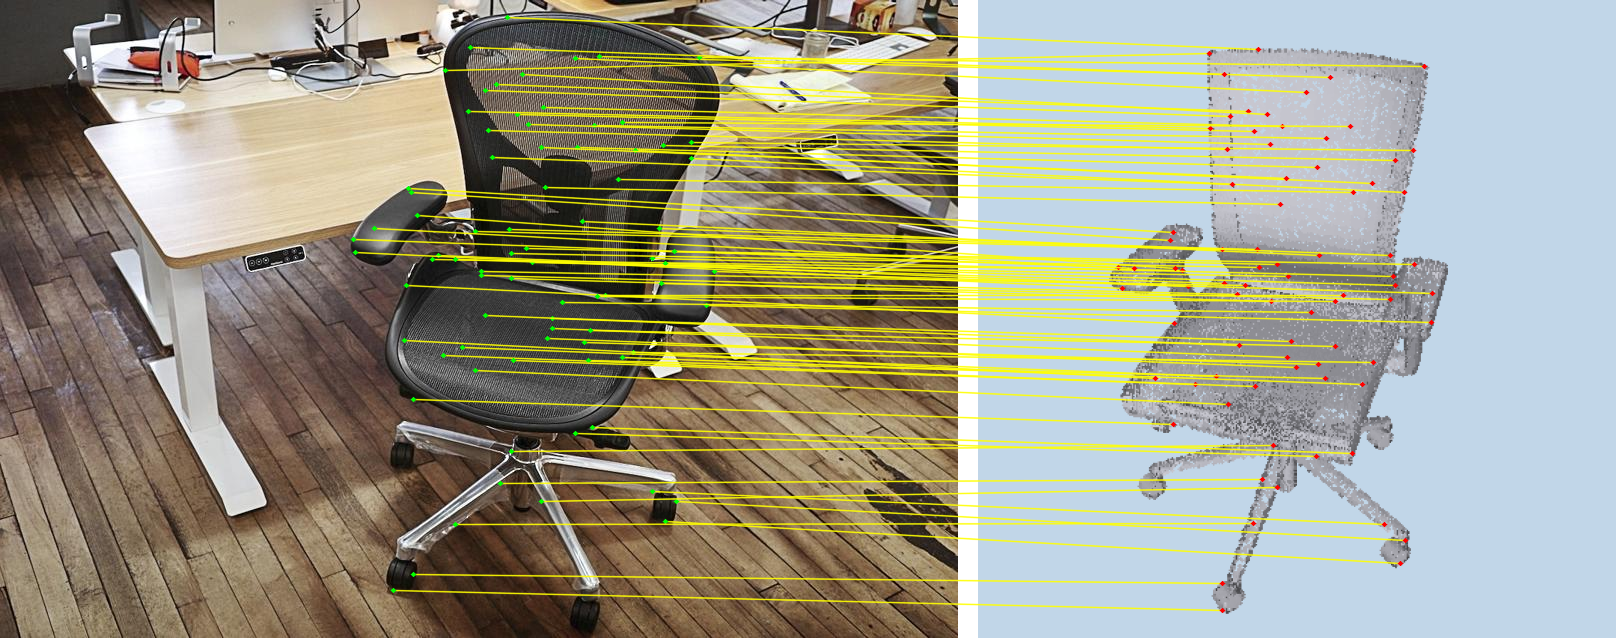

In [7]:
correspondences = make_correspondence_image(
    color_path=color_path,
    alignment_result=result,
    intrinsic=intrinsic,
    shapenet_root=SHAPENET_ROOT,
    output_path=DEMO_DIR / 'correspondences.png',
    max_lines=80,
)
print(f"inlier correspondences: {len(result['match_source_points'])}")
correspondences

## 7. Overlay the aligned CAD

The aligned CAD projected through the predicted transform and painted over the image with a red border. Dense from the ShapeNet mesh with `SHAPENET_ROOT`, else sparse render-frame points.

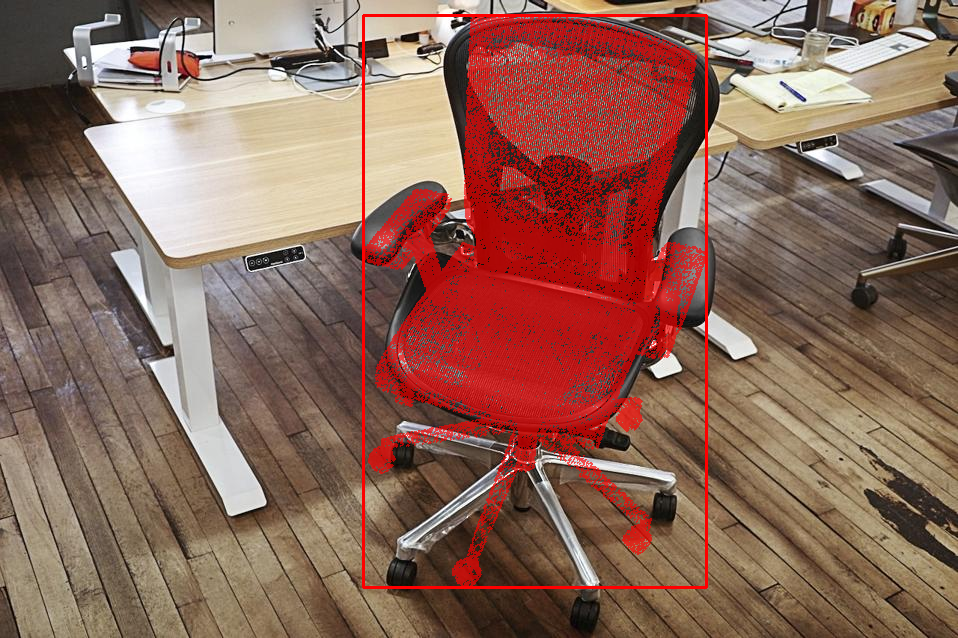

In [8]:
overlay = make_cad_overlay_image(
    color_path=color_path,
    alignment_result=result,
    intrinsic=intrinsic,
    output_path=DEMO_DIR / 'cad_overlay.png',
    border_px=2,
    shapenet_root=SHAPENET_ROOT,
)
overlay

## 8. 3D alignment view

The back-projected object plus the transformed CAD points and predicted axes in 3D. Static snapshot below; an interactive HTML copy is saved alongside.

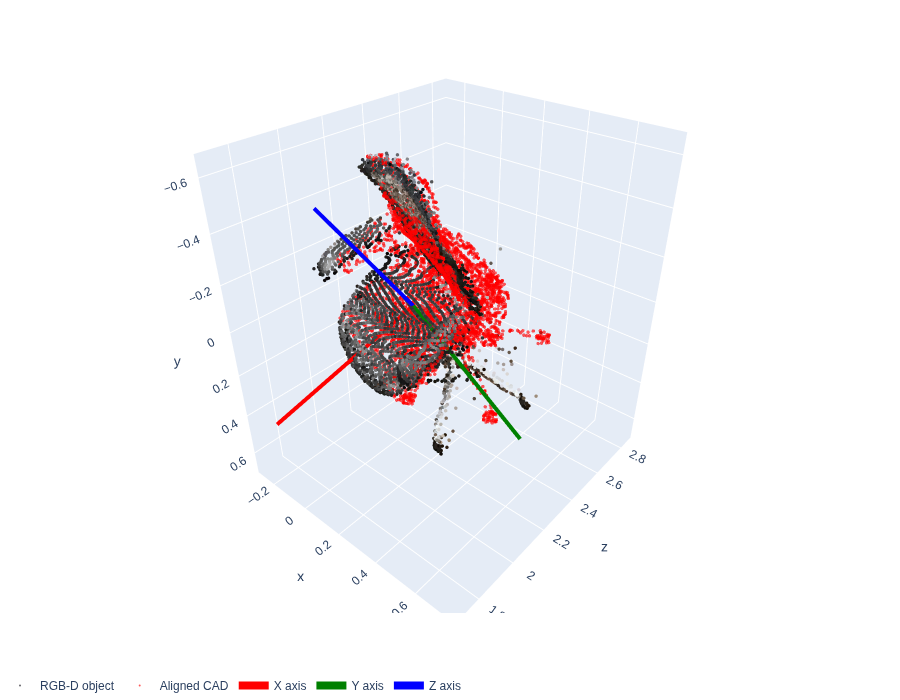

In [9]:
from IPython.display import Image as IPyImage

fig = make_alignment_3d_figure(
    color_path=color_path,
    depth_path=depth_path,
    mask_path=mask_path,
    inst_id=inst_id,
    alignment_result=result,
    intrinsic=intrinsic,
    output_html=DEMO_DIR / 'alignment_3d.html',
    shapenet_root=SHAPENET_ROOT,
)
# Static snapshot for any viewer; interactive HTML saved alongside.
fig.write_image(DEMO_DIR / 'alignment_3d.png', width=900, height=700)
IPyImage(filename=str(DEMO_DIR / 'alignment_3d.png'))